# Sentinel-1 Snow Depth Retrievals

This notebook is designed to obtain snow depth from Sentinel-1 C-band data. Because their is no formal snow depth product for Sentinel-1, multiple studies have published on a change detection method to derive depth.

This notebook uses `spicy_snow`, a Python package developed by Zach Hoppinen (zmhoppinen@alaska.edu), to perform the snow depth derivations. By providing an AOI, date range, data path, and resolution, `spicy_snow` performs the data downloading and processing under the hood.

Note that `spicy_snow` requires the Alaska Satellite Facility's search module (`asf_search`) and `earthaccess` as dependencies to download the Sentinel-1 data and VIIRS snow cover data, respectively. It is also recommended to keep queries within the **Continental United States**, otherwise data requests may take much longer or fail when attempting to access forest cover data.

If the user does not have `spicy_snow` downloaded, then they should run the below cell.

In [ ]:
!pip install spicy_snow

Once `spicy_snow` is downloaded, obtaining Sentinel-1 snow depths only takes 1-2 blocks of code. However, be aware that if a range of dates is queried, such as in the example below, then 100s-1000s of files will be downloaded for processing. If running this notebook on CryoCloud, then it is highly recommended to use a small date range, or a selection of dates, a small ROI, and the coarsest resolution (1 km/1000 m).

In [1]:
import geopandas as gpd
from pathlib import Path
from spicy_snow.retrieval import retrieve_snow_depth

# SW/NE corners of AOI
test_aoi = [-119.85, 37.71, -119.1, 38.25]

# Date range - note that the initial date is before snowfall
dates = ['2020-10-01', '2020-12-01']

# Path for output netCDF file
out_nc = Path('/home/jovyan/tmp/test.nc').resolve()

# Resolution of final product, in meters
spatial_resolution = 1000

# data source can be either "opera" RTC or "hyp3" cloud processed
# opera is much faster and doesn't require hyp3 credits
# hyp3 uses gamma processing and may be cleaner
source = 'opera'

# Perform data query and processing
spicy_ds = retrieve_snow_depth(aoi=test_aoi, 
                               dates=dates, 
                               work_dir=Path('/home/jovyan/tmp/').resolve(), 
                               resolution=spatial_resolution,
                               outfp=out_nc)

(spicy-snow spicy_snow.retrieval INFO) Downloading sentinel-1 gamma0 backscatter data
(spicy-snow asf_search INFO) SEARCH: Using search opts {
    "intersectsWith": "POLYGON ((-119.0999999999999943 37.7100000000000009, -119.0999999999999943 38.2500000000000000, -119.8499999999999943 38.2500000000000000, -119.8499999999999943 37.7100000000000009, -119.0999999999999943 37.7100000000000009))",
    "platform": [
        "SENTINEL-1C",
        "SENTINEL-1B",
        "SENTINEL-1A"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-10-01T00:00:00Z",
    "end": "2020-12-01T00:00:00Z"
}
(spicy-snow asf_search INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow asf_search INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POLYGON ((-119.0999999999999943 37.7100000000000009, -119.0999999999999943 38.2500000000000000, -119.8499999999999943 38.2500000000000000, -119.8499999999999943 37.7100000000000009, -

Downloading:   0%|          | 0/831 [00:00<?, ?it/s]

/srv/conda/envs/notebook/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Reprojecting + inserting vv:   0%|          | 0/277 [00:00<?, ?it/s]

Reprojecting + inserting vh:   0%|          | 0/277 [00:00<?, ?it/s]

(spicy-snow spicy_snow.retrieval INFO) Downloading VIIRS snowcover data
(spicy-snow earthaccess.api INFO) Granules found: 62


Downloading:   0%|          | 0/31 [00:00<?, ?it/s]

(spicy-snow spicy_snow.retrieval INFO) Downloading forest cover fraction data
(spicy-snow spicy_snow.processing.generate_dataarrays INFO) AOI inside of CONUS. NLCD 2021 Forest Cover
(spicy-snow spicy_snow.retrieval INFO) Preprocessing Sentinel-1 images
(spicy-snow spicy_snow.retrieval INFO) Calculating snow index
(spicy-snow spicy_snow.retrieval INFO) Flag wet snow


In summary, the above code downloads the Sentinel-1 data, adds the polarized data, downloads and adds VIIRS snow cover data, downloads and adds NLCD forest cover data, and calculates snow depth. The results are all saved into a netCDF file.

Let's take a look at the data we just produced:

In [2]:
import xarray as xr

ds = xr.open_dataset('/home/jovyan/tmp/test.nc')

`spicy_snow` automatically georeferences our data variables, so there's no need to map coordinates. Let's take a look at the snow cover product.

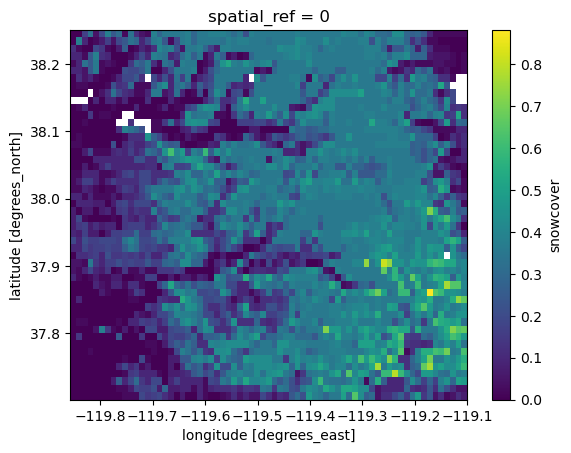

In [7]:
# Plot time-averaged map of VIIRS snow cover
ds['snowcover'].mean(dim=('time')).plot()

Of course, we can also examine snow depth over the domain.

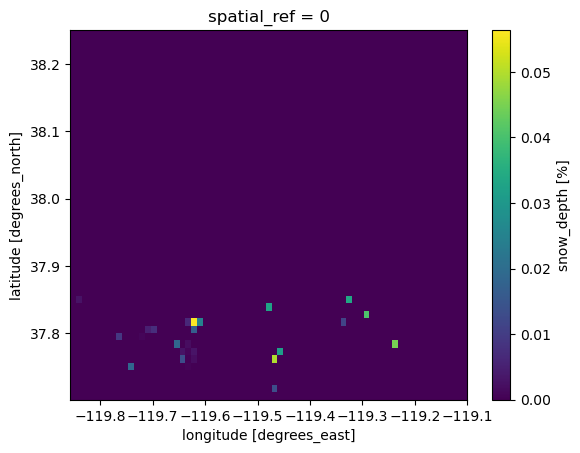

In [8]:
ds['snow_depth'].mean(dim=('time')).plot()

The above map shows much less data than the snow cover product. This is to be expected! Between the early timing in the snow season (December) and the forest cover in this region, there is not a lot of data available for data estimation. We will likely require a larger collection of data if we want a more complete map of the region.

## References for the retrieval method (and Python package)

Lievens et al., (2019): https://www.nature.com/articles/s41467-019-12566-y

Lievens et al., (2021): https://tc.copernicus.org/articles/16/159/2022/

Hoppinen et al., (2024): https://tc.copernicus.org/articles/18/5407/2024/